In [1]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
from plot_progress import gather_metrics
from parse_levels import find_levels_in_configs, find_levels_in_configs_glob
from parse_levels import process_metrics, human_train_time_dict, convert_to_dict, compute_gap_in_percentage
from parse_levels import filter_folder_info
import pandas as pd
import matplotlib.ticker as ticker
from plot_utils import plot_gap_comparison
import re
import copy
import json

In [2]:
# for each item in the dict, if any two have the same 'record', remove the one with lower number of steps in metric
def deduplicate_metrics(search_results):
    records_length_so_far = {}
    new_search_results = {}
    for key, value in search_results.items():
        if value['record'] not in records_length_so_far:
            records_length_so_far[value['record']] = (len(value['metrics']['step']), key)
            new_search_results[key] = value
        else:
            if len(value['metrics']['step']) > records_length_so_far[value['record']][0]:
                new_search_results.pop(records_length_so_far[value['record']][1])

                records_length_so_far[value['record']] = (len(value['metrics']['step']), key)
                new_search_results[key] = value
    return new_search_results



In [3]:
# ori_results = find_levels_in_configs_glob(
#     [
#         '/checkpoint/maui/zhaobc/scientist/workspace/record_*',
#         # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250424_*',
#         # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250425_*',
#         # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250405_*'
#         # '/checkpoint/maui/zhaobc/scientist/workspace/record_1[2-8]_20250412_*',
#         #  '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250408_*',
#         # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250405_*'
#         # '/checkpoint/maui/zhaobc/scientist/workspace/record_1[2-8]_20250409_*',
#     ]
# )
with open('results.cache', 'r') as f:
    ori_results = json.load(f)

In [4]:
folder_info = ori_results

In [5]:
len(folder_info)

888

In [6]:
# flat search -- n_initial_hypotheses = 50
flat_params = [
    ('runner', 'bon'),
    ('n_initial_hypotheses', 50),
]
# tree search -- n_initial_hypotheses = 1, n_hypotheses = 3
tree_params = [
    ('runner', 'bon'),
    ('n_initial_hypotheses', 1),
    ('n_hypotheses', 3),
]
# forest search -- n_initial_hypotheses = 3, n_hypotheses = 3
forest_params = [
    ('runner', 'bon'),
    ('n_initial_hypotheses', 3),
    ('n_hypotheses', 3),
]
# AIDE -- n_initial_hypotheses = 3, n_hypotheses = 1, debug_prob = 0.5
aide_params = [
    ('runner', 'aide'),
    ('n_initial_hypotheses', 3),
    ('n_hypotheses', 1),
    ('debug_prob', 0.5),
]
# MultiAIDE -- n_initial_hypotheses = 3, n_hypotheses = 3, debug_prob = 0.5
multi_aide_params = [
    ('runner', 'aide'),
    ('n_initial_hypotheses', 3),
    ('n_hypotheses', 3),
    ('debug_prob', 0.5),
]
# for each search algo, we get the R1 and O3 with level 1, 12, 125 results for plotting
# thats 6 results for each search algo, so we plot with 3 columns (level) and 2 rows (R1 and O3)

search_algo_params = {
    'flat': flat_params,
    'tree': tree_params,
    'forest': forest_params,
    'aide': aide_params,
    'multi_aide': multi_aide_params,
}

plot_info = {}

for search_algo, params in search_algo_params.items():
    plot_info[search_algo] = {}
    for level in [1, 12, 125]:
        plot_info[search_algo][level] = {}
        for model in ['deepseek-r1', 'o3-mini']:
            search_params = params + [('levels', level), ('model', model)]
            filtered_folder_info = filter_folder_info(folder_info, search_params)
            print(f'{search_algo} {level} {model} {len(filtered_folder_info)}')
            plot_info[search_algo][level][model] = filtered_folder_info



flat 1 deepseek-r1 18
flat 1 o3-mini 18
flat 12 deepseek-r1 18
flat 12 o3-mini 18
flat 125 deepseek-r1 18
flat 125 o3-mini 18
tree 1 deepseek-r1 18
tree 1 o3-mini 18
tree 12 deepseek-r1 18
tree 12 o3-mini 18
tree 125 deepseek-r1 18
tree 125 o3-mini 18
forest 1 deepseek-r1 18
forest 1 o3-mini 18
forest 12 deepseek-r1 18
forest 12 o3-mini 18
forest 125 deepseek-r1 36
forest 125 o3-mini 36
aide 1 deepseek-r1 18
aide 1 o3-mini 18
aide 12 deepseek-r1 46
aide 12 o3-mini 36
aide 125 deepseek-r1 46
aide 125 o3-mini 46
multi_aide 1 deepseek-r1 18
multi_aide 1 o3-mini 18
multi_aide 12 deepseek-r1 18
multi_aide 12 o3-mini 18
multi_aide 125 deepseek-r1 34
multi_aide 125 o3-mini 26


In [7]:
figure_data = {}
for search_algo in search_algo_params.keys():
    for level in [1, 12, 125]:
        for model in ('deepseek-r1', 'o3-mini'):
            plot_info[search_algo][level][model] = process_metrics(plot_info[search_algo][level][model])
            plot_info[search_algo][level][model] = deduplicate_metrics(plot_info[search_algo][level][model])
            figure_data[f'{search_algo}_{level}_{model}'] = convert_to_dict(plot_info[search_algo][level][model])


In [8]:
train_time_std = {
    1: 20183.68,
    2: 18300.36, 
    3: 22270.99,
    4: 37980.47,
    5: 7365.53,
    6: 5922.16,
    7: 3805.14,
    8: 9496.43,
    9: 15747.18,
    10: 2315.29,
    11: 3259.97,
    12: 1220.16,
    13: 927.61,
    14: 6034.27,
    15: 2337.85,
    16: 6700.25,
    17: 40.5,
    18: 1495.18,
    19: 600.67,
    20: 770.64,
    21: 593.64
}

In [9]:

    gaps = {}
    for k, v in human_train_time_dict.items():
        if (k + 1) not in human_train_time_dict:
            continue
        gaps[k] = v - human_train_time_dict[k+1]

In [10]:
std_percentage = {}
for k, v in gaps.items():
    std_percentage[k] = train_time_std[k] / v


In [11]:
for key in figure_data.keys():
    figure_data[key] = compute_gap_in_percentage(figure_data[key])
    figure_data[key] = {str(k): v for k, v in figure_data[key].items()}
    del figure_data[key]['6']

In [12]:
std_percentage = {str(k): v for k, v in std_percentage.items()}

In [13]:
# replace the ones with 300% improvement with 0 as they might be summarizer mistakes
for key in figure_data.keys():
    for k, v in figure_data[key].items():
        if v > 3 or v < 0:
            figure_data[key][k] = 0.

In [14]:
# each model, each level, each search algo, we get a number that is the averaged percetage gap and pass@50%
figure_data.keys()
table_data = {}
for search in ['flat', 'tree', 'forest', 'aide', 'multi_aide']:
    table_data[search] = {}
    for level in [1, 12, 125]:
        table_data[search][level] = {}
        for model in ['deepseek-r1', 'o3-mini']:
            values = figure_data[f'{search}_{level}_{model}'].values()
            avg_percentage = sum(values) / len(values)
            pass_50 = sum(1 for v in values if v >= 0.5)  # count values > 50%
            table_data[search][level][model] = {
                'avg': avg_percentage,
                'pass@50%': pass_50
            }


In [15]:
# Create dataframe for deepseek-r1
deepseek_df_per = pd.DataFrame(
    {search: {level: table_data[search][level]['deepseek-r1']['avg']
             for level in [1, 12, 125]}
     for search in ['flat', 'tree', 'forest', 'aide', 'multi_aide']})

# Create dataframe for o3-mini  
o3_df_per = pd.DataFrame(
    {search: {level: table_data[search][level]['o3-mini']['avg']
             for level in [1, 12, 125]} 
     for search in ['flat', 'tree', 'forest', 'aide', 'multi_aide']})

print("Average time reduction percentage")
print("Deepseek-r1:")
print(deepseek_df_per)
print("\nO3-mini:")
print(o3_df_per)

# Create dataframe for deepseek-r1
deepseek_df_pass = pd.DataFrame(
    {search: {level: f"{table_data[search][level]['deepseek-r1']['pass@50%']}/16"
             for level in [1, 12, 125]}
     for search in ['flat', 'tree', 'forest', 'aide', 'multi_aide']}
)

# Create dataframe for o3-mini  
o3_df_pass = pd.DataFrame(
    {search: {level: f"{table_data[search][level]['o3-mini']['pass@50%']}/16"
             for level in [1, 12, 125]} 
     for search in ['flat', 'tree', 'forest', 'aide', 'multi_aide']}
)

print("Pass@50%")
print("Deepseek-r1:")
print(deepseek_df_pass)
print("\nO3-mini:")
print(o3_df_pass)

Average time reduction percentage
Deepseek-r1:
         flat      tree    forest      aide  multi_aide
1    0.432736  0.239397  0.077478  0.153744    0.182068
12   0.285321  0.145057  0.485767  0.389881    0.400670
125  0.374141  0.420214  0.522341  0.370704    0.493392

O3-mini:
         flat      tree    forest      aide  multi_aide
1    0.437768  0.414583  0.347951  0.437201    0.326087
12   0.469600  0.406840  0.451358  0.501255    0.445816
125  0.638741  0.677204  0.569546  0.594289    0.539397
Pass@50%
Deepseek-r1:
     flat  tree forest  aide multi_aide
1    7/16  2/16   1/16  2/16       3/16
12   3/16  3/16   7/16  5/16       5/16
125  5/16  6/16   8/16  5/16       7/16

O3-mini:
     flat   tree forest  aide multi_aide
1    6/16   7/16   6/16  8/16       5/16
12   7/16   6/16   6/16  7/16       7/16
125  9/16  11/16   8/16  9/16       8/16


In [19]:
from analyze_embeddings import aggregate_and_print

In [17]:
df_path = '/checkpoint/maui/minqijiang/nanoasi/nanogpt_embed_df.csv'
df = pd.read_csv(df_path)

In [20]:
df = aggregate_and_print(df)

    method   model  record  levels  cos_start_mean  cos_end_mean  l2_start_mean  l2_end_mean
      flat o3-mini       1      12    5.960464e-08      0.011788       0.000000    23.560734
      flat o3-mini       1     125    1.023269e-02      0.006881      21.953444    18.048616
      flat o3-mini       2      12    2.962351e-04      0.035446       3.745340    40.894482
      flat o3-mini       2     125    5.960464e-08      0.035829       0.000000    41.109798
      flat o3-mini       3      12   -1.192093e-07      0.040896       0.000000    43.555946
      flat o3-mini       3     125   -1.192093e-07      0.040896       0.000000    43.555946
      flat o3-mini       4      12    2.892375e-03      0.004706      11.513902    14.679791
      flat o3-mini       4     125    4.094303e-03      0.004215      13.722095    13.927388
      flat o3-mini       5      12    1.192093e-07      0.009112       0.000000    20.360479
      flat o3-mini       5     125    5.657852e-03      0.006863      

In [21]:
plot_df = df[df["levels"].isin([12, 125])]
plot_df = plot_df[plot_df["model"].isin(['deepseek-r1', 'o3-mini'])]
uniq_pairs = plot_df[["model", "levels"]].drop_duplicates()
plot_df.head()


,method,model,record,levels,cos_start_mean,cos_end_mean,l2_start_mean,l2_end_mean
0,flat,o3-mini,1,12,5.960464e-08,0.011788,0.000000,23.560734
1,flat,o3-mini,1,125,1.023269e-02,0.006881,21.953444,18.048616
2,flat,o3-mini,2,12,2.962351e-04,0.035446,3.745340,40.894482
3,flat,o3-mini,2,125,5.960464e-08,0.035829,0.000000,41.109798
4,flat,o3-mini,3,12,-1.192093e-07,0.040896,0.000000,43.555946


In [ ]:
pl

In [26]:
l2_end_dict = {}
for (meth, mdl, lvl), sub in plot_df.groupby(["method", "model", "levels"]):
    if meth not in l2_end_dict:
        l2_end_dict[meth] = {}
    if mdl not in l2_end_dict[meth]:
        l2_end_dict[meth][mdl] = {}
    if lvl not in l2_end_dict[meth][mdl]:
        l2_end_dict[meth][mdl][lvl] = {}
    sub = sub.sort_values("record")
    # average l2_end_mean 
    l2_end_dict[meth][mdl][lvl] = sub["l2_end_mean"].mean()


In [33]:
l2_end_dict['flat']['o3-mini'][12]

25.213670200771755

In [34]:
table_data['flat'][12]['o3-mini']


{'avg': 0.4696000383160497, 'pass@50%': 7}

In [37]:
l2_end_dict.keys()

dict_keys(['flat', 'forest', 'multi_aide', 'ori_aide', 'tree'])

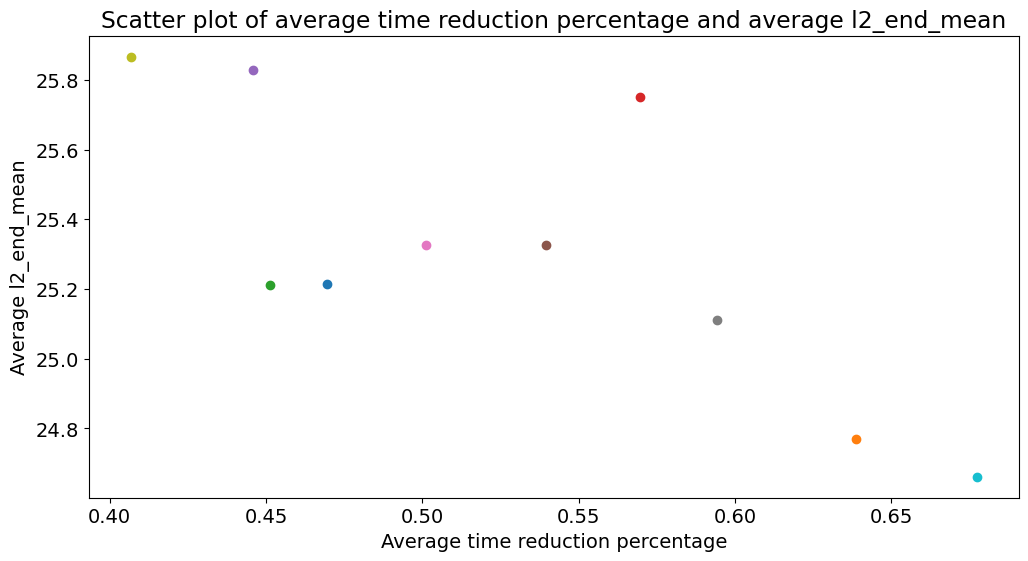

In [ ]:
# use the model o3-mini, and use the value in table_data as x-axis, value in l2_end_dict as y-axis, plot the scatter plot
# iterate over the method and levels
for meth in l2_end_dict.keys():
    for lvl in l2_end_dict[meth]['o3-mini'].keys():
        plt.scatter(table_data[meth if meth != 'ori_aide' else 'aide'][lvl]['o3-mini']['avg'], l2_end_dict[meth]['o3-mini'][lvl])

plt.xlabel('Average time reduction percentage')
plt.ylabel('Average l2_end_mean')
# plt.title('Scatter plot of average time reduction percentage and average l2_end_mean')
plt.show()


